In [3]:
import re
import io
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px

In [4]:
df = pd.read_csv(
    "road_accidents_cleaned.csv"
)

In [5]:

# Focus on 2017 only
df = df[df["year"] == 2017].copy()
print(f"{len(df):,} records in 2017")
print(df["date"].min(), "to", df["date"].max())

740 records in 2017
2017-02-22 to 2017-11-06


In [6]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 60)

In [7]:
df.columns

Index(['accident_id', 'time', 'base_sub_base', 'county', 'road', 'place',
       'vehicles_involved', 'accident_details', 'gender', 'age', 'cause_code',
       'victim_type', 'number', 'date', 'county_raw', 'gender_raw',
       'victim_type_raw', 'age_raw', 'age_numeric', 'age_category',
       'age_group', 'date_raw', 'year', 'month', 'month_name', 'day',
       'day_name', 'time_raw', 'hour', 'minute', 'time_period',
       'cause_code_raw', 'cause_group', 'vehicles_involved_raw', 'motorcycle',
       'matatu', 'bus', 'lorry_truck', 'pickup', 'tractor', 'car_suv',
       'unknown_vehicle', 'trailer_tanker', 'vehicle_classified',
       'van_minivan', 'unspecified_vehicle'],
      dtype='str')

In [7]:
df.describe()


,accident_id,cause_code,number,age_numeric,year,month,day,hour,minute,cause_code_raw
count,740.000000,718.000000,736.000000,326.000000,740.0,740.000000,740.000000,721.000000,721.000000,718.000000
mean,748.500000,47.682451,1.199728,35.588957,2017.0,6.556757,16.648649,14.427184,20.862691,47.682451
std,213.763888,33.091682,1.078951,15.839864,0.0,2.396043,8.607409,6.260372,16.836609,33.091682
min,379.000000,4.000000,1.000000,2.000000,2017.0,2.000000,1.000000,0.000000,0.000000,4.000000
25%,563.750000,19.250000,1.000000,26.000000,2017.0,5.000000,10.000000,10.000000,0.000000,19.250000
50%,748.500000,37.000000,1.000000,33.500000,2017.0,7.000000,18.000000,16.000000,30.000000,37.000000
75%,933.250000,76.000000,1.000000,44.750000,2017.0,8.000000,23.000000,20.000000,30.000000,76.000000
max,1118.000000,99.000000,18.000000,80.000000,2017.0,11.000000,31.000000,23.000000,56.000000,99.000000


In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 740 entries, 378 to 1117
Data columns (total 51 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   accident_id            740 non-null    int64         
 1   time                   737 non-null    str           
 2   base_sub_base          738 non-null    str           
 3   county                 740 non-null    str           
 4   road                   737 non-null    str           
 5   place                  734 non-null    str           
 6   vehicles_involved      740 non-null    str           
 7   accident_details       740 non-null    str           
 8   gender                 740 non-null    str           
 9   age                    739 non-null    str           
 10  cause_code             718 non-null    float64       
 11  victim_type            740 non-null    str           
 12  number                 736 non-null    float64       
 13  date         

In [59]:
# Standardise text columns we'll group on, and fix obvious NaNs
text_cols = ["county", "road", "place", "victim_type", "gender",
             "cause_group", "time_period", "month_name", "day_name"]
for c in text_cols:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip().str.upper()
        df[c] = df[c].replace({"NAN": np.nan, "": np.nan})

In [60]:
# Drop rows where county is totally missing for county-level analysis
df["county"] = df["county"].replace({"NONE": np.nan})

In [61]:
# Make sure date is parsed
df["date"] = pd.to_datetime(df["date"], errors="coerce")
 
print(df["county"].nunique(), "counties recorded")
print(df["date"].min(), "to", df["date"].max())

42 counties recorded
2017-02-22 00:00:00 to 2017-11-06 00:00:00



### Q1. Which counties have the highest number of recorded road accidents?
 Each row = one victim record, so we count rows per county (accident *impact*,
 not unique crash events — that's fine for "recorded accidents" framing since
 the CSV is victim-level).

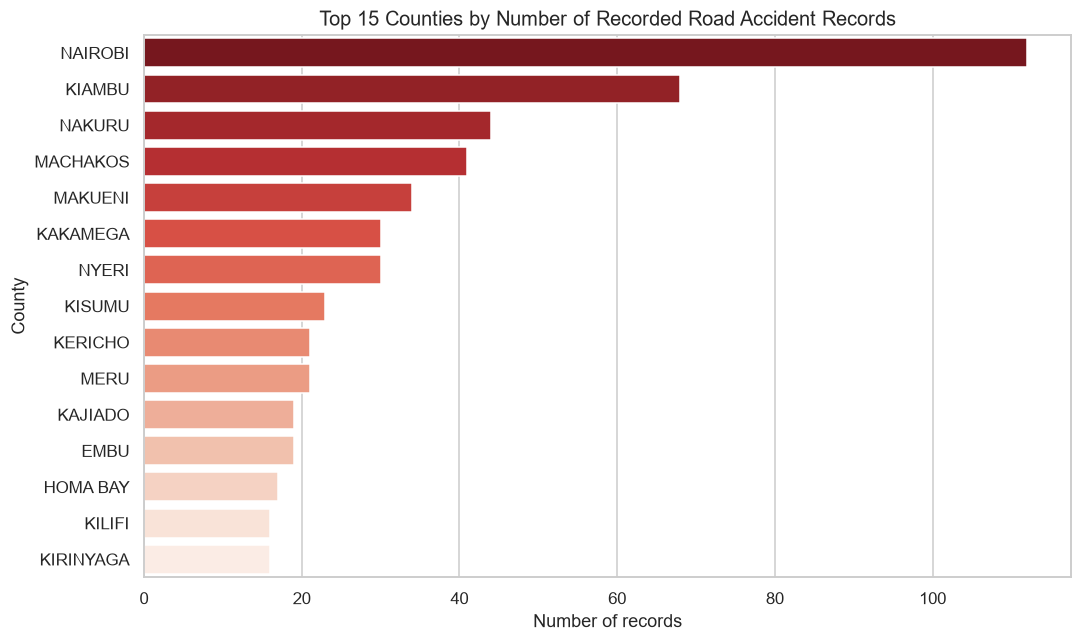

In [62]:
top_counties = df["county"].value_counts().head(15)
 
plt.figure(figsize=(10, 6))
sns.barplot(x=top_counties.values, y=top_counties.index, palette="Reds_r", hue=top_counties.index, legend=False)
plt.title("Top 15 Counties by Number of Recorded Road Accident Records", fontsize=13)
plt.xlabel("Number of records")
plt.ylabel("County")
plt.tight_layout()
plt.show()

 ### Q2. Which roads and locations record the highest number of accidents?
 We look at `road` (the named highway/route) and `place` (specific spot)
 separately, since "place" alone repeats across counties (e.g. "NEAR SHELL
 PETROL STATION").

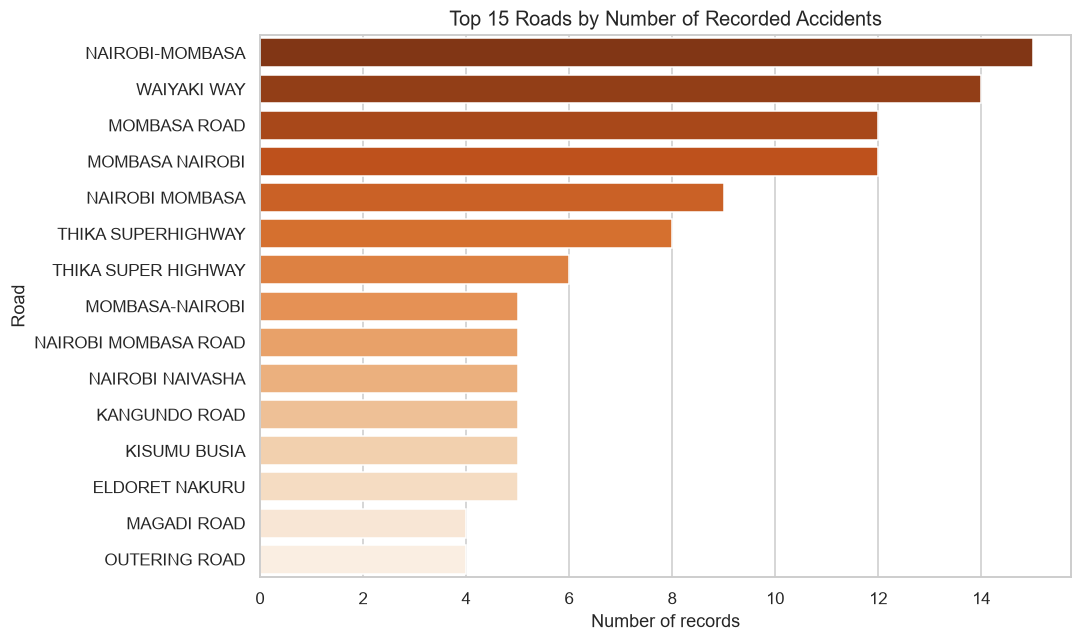

In [63]:
top_roads = df["road"].value_counts().head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_roads.values, y=top_roads.index, palette="Oranges_r", hue=top_roads.index, legend=False)
plt.title("Top 15 Roads by Number of Recorded Accidents", fontsize=13)
plt.xlabel("Number of records")
plt.ylabel("Road")
plt.tight_layout()
plt.show()

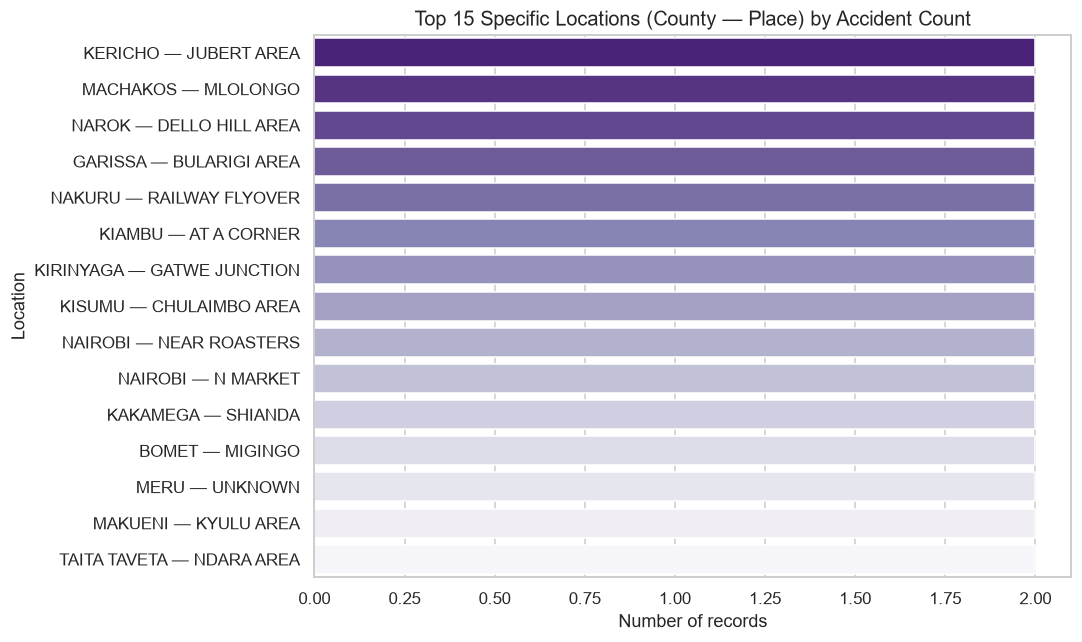

In [64]:
# Combine county + place for a more specific "location" signature
df["location_signature"] = df["county"].fillna("UNKNOWN") + " — " + df["place"].fillna("UNKNOWN")
top_places = df["location_signature"].value_counts().head(15)
 
plt.figure(figsize=(10, 6))
sns.barplot(x=top_places.values, y=top_places.index, palette="Purples_r", hue=top_places.index, legend=False)
plt.title("Top 15 Specific Locations (County — Place) by Accident Count", fontsize=13)
plt.xlabel("Number of records")
plt.ylabel("Location")
plt.tight_layout()
plt.show()

### Q3. What types of road users are most affected by road accidents?
Using the `victim_type` column (pedestrian, motorcyclist, passenger, driver, etc.)

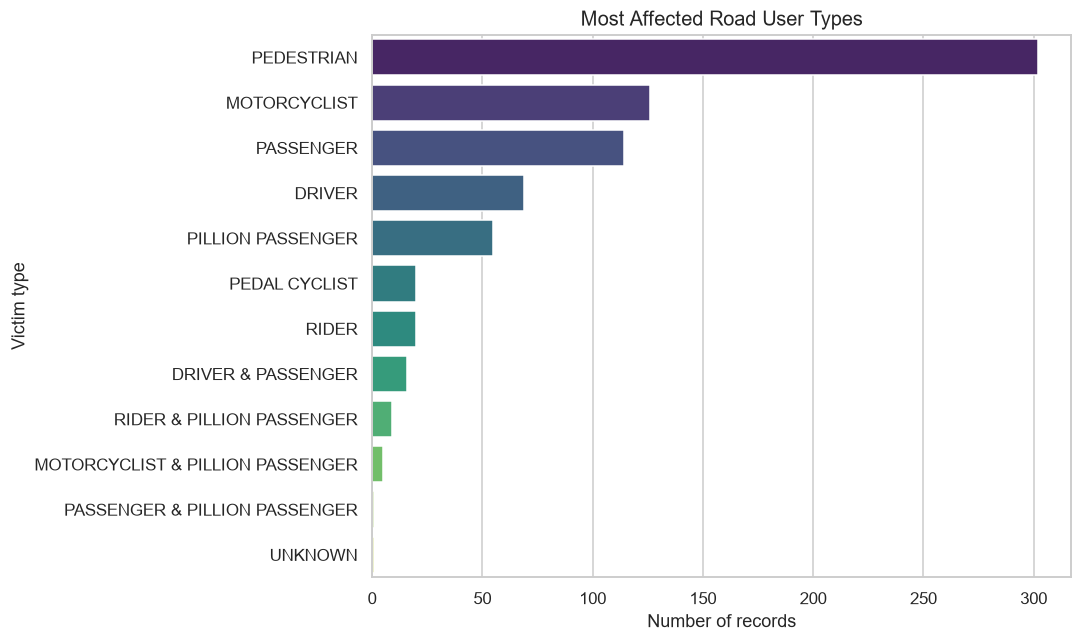

In [65]:
victim_counts = df["victim_type"].value_counts().head(12)
 
plt.figure(figsize=(10, 6))
sns.barplot(x=victim_counts.values, y=victim_counts.index, palette="viridis", hue=victim_counts.index, legend=False)
plt.title("Most Affected Road User Types", fontsize=13)
plt.xlabel("Number of records")
plt.ylabel("Victim type")
plt.tight_layout()
plt.show()

### Q4. At what times of the day are accidents most frequently recorded?
Use `time_period` (MORNING/AFTERNOON/EVENING/NIGHT) and hour-level detail.

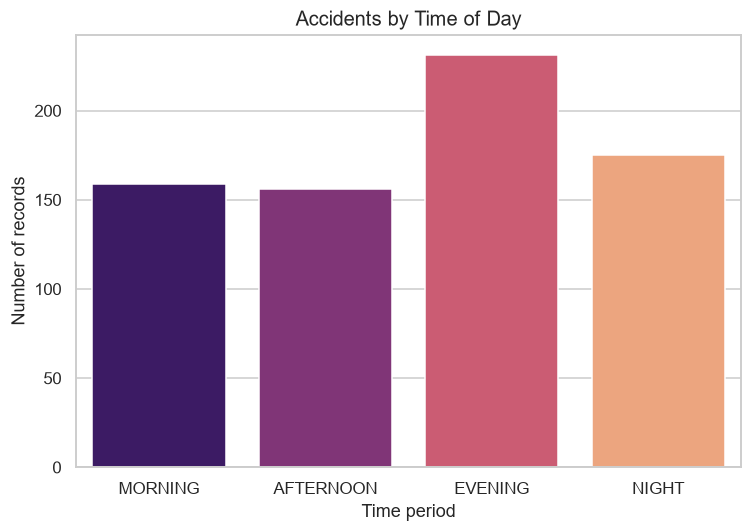

In [66]:
period_order = ["MORNING", "AFTERNOON", "EVENING", "NIGHT"]
period_counts = df["time_period"].value_counts().reindex(period_order).dropna()
 
plt.figure(figsize=(7, 5))
sns.barplot(x=period_counts.index, y=period_counts.values, palette="magma", hue=period_counts.index, legend=False)
plt.title("Accidents by Time of Day", fontsize=13)
plt.xlabel("Time period")
plt.ylabel("Number of records")
plt.tight_layout()
plt.show()

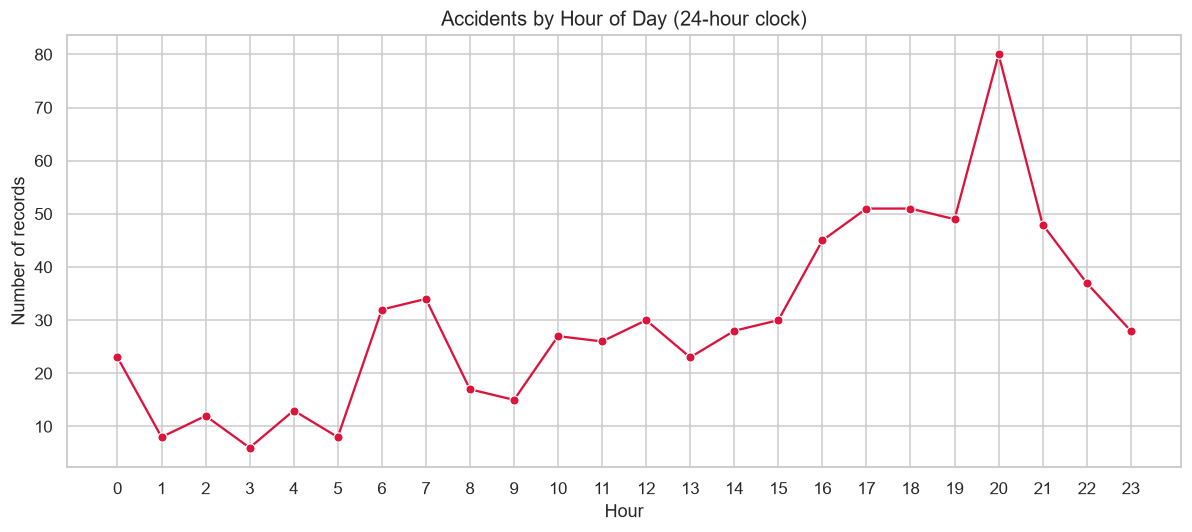

In [67]:
# Finer detail: distribution across the 24-hour clock
hourly = df["hour"].value_counts().sort_index()
 
plt.figure(figsize=(11, 5))
sns.lineplot(x=hourly.index, y=hourly.values, marker="o", color="crimson")
plt.title("Accidents by Hour of Day (24-hour clock)", fontsize=13)
plt.xlabel("Hour")
plt.ylabel("Number of records")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()
 

### Q5. How does accident involvement differ by gender?

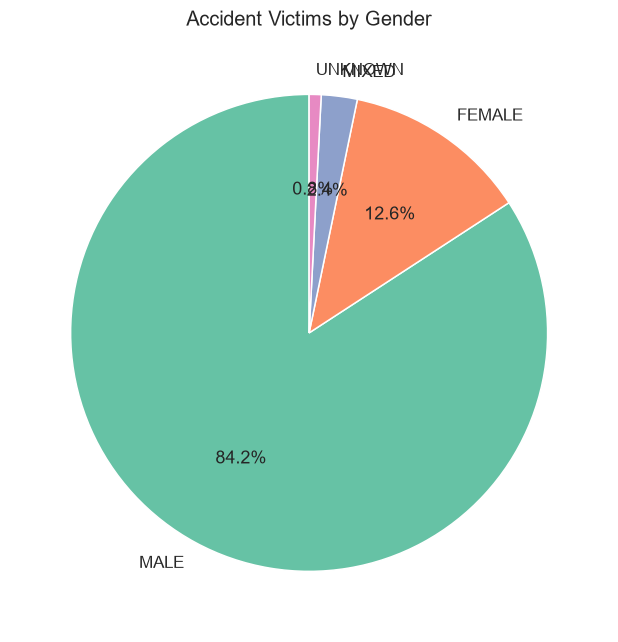

In [68]:
gender_counts = df["gender"].value_counts()
 
plt.figure(figsize=(6, 6))
colors = sns.color_palette("Set2")
plt.pie(gender_counts.values, labels=gender_counts.index, autopct="%1.1f%%",
        colors=colors, startangle=90)
plt.title("Accident Victims by Gender", fontsize=13)
plt.tight_layout()
plt.show()

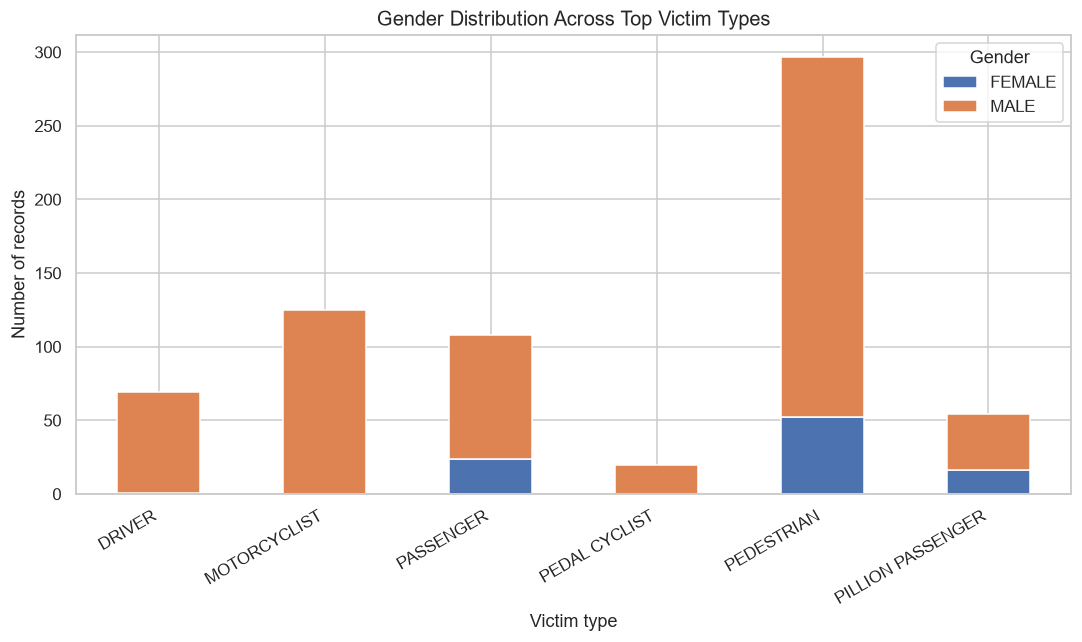

In [69]:
# Gender broken down by victim type (are men more affected as motorcyclists? women as pedestrians?)
top_victim_types = df["victim_type"].value_counts().head(6).index
gv = (
    df[df["victim_type"].isin(top_victim_types) & df["gender"].isin(["MALE", "FEMALE"])]
    .groupby(["victim_type", "gender"])
    .size()
    .unstack(fill_value=0)
)
 
gv.plot(kind="bar", stacked=True, figsize=(10, 6), color=["#4C72B0", "#DD8452"])
plt.title("Gender Distribution Across Top Victim Types", fontsize=13)
plt.xlabel("Victim type")
plt.ylabel("Number of records")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()
 

### Q6. What are the most commonly recorded accident causes?
 `cause_group` gives a clean high-level bucket; `cause_code_raw`/description
 columns are messier free text, so we stick to the grouped version.
 

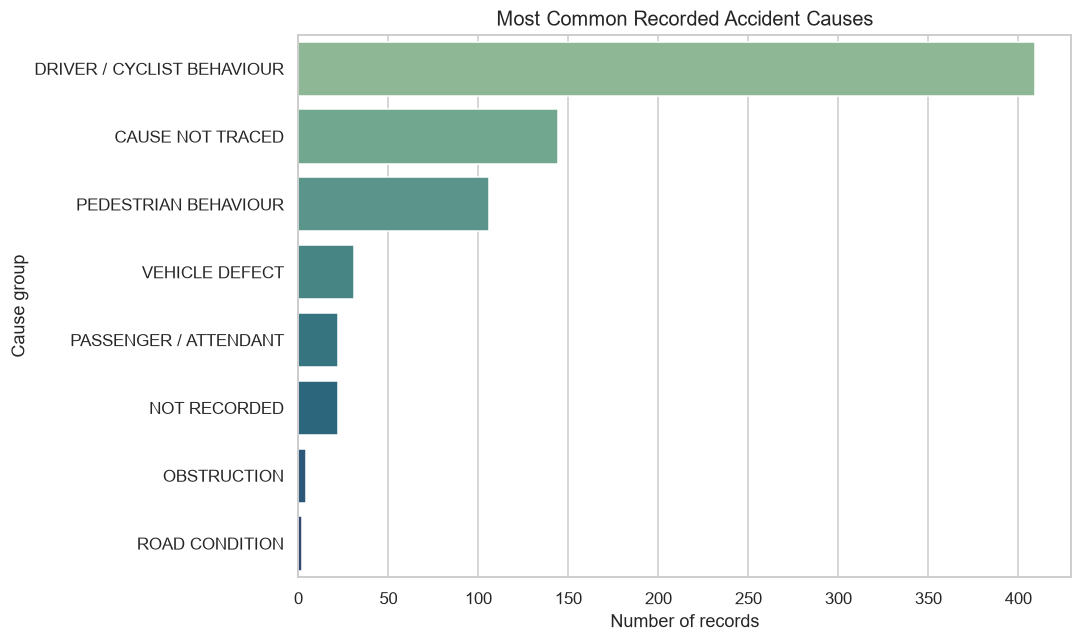

In [70]:
cause_counts = df["cause_group"].value_counts()
 
plt.figure(figsize=(10, 6))
sns.barplot(x=cause_counts.values, y=cause_counts.index, palette="crest", hue=cause_counts.index, legend=False)
plt.title("Most Common Recorded Accident Causes", fontsize=13)
plt.xlabel("Number of records")
plt.ylabel("Cause group")
plt.tight_layout()
plt.show()
 

### Q7. Which types of vehicles are most frequently involved in accidents?
The dataset has one-hot boolean columns per vehicle type, so we sum them.
 

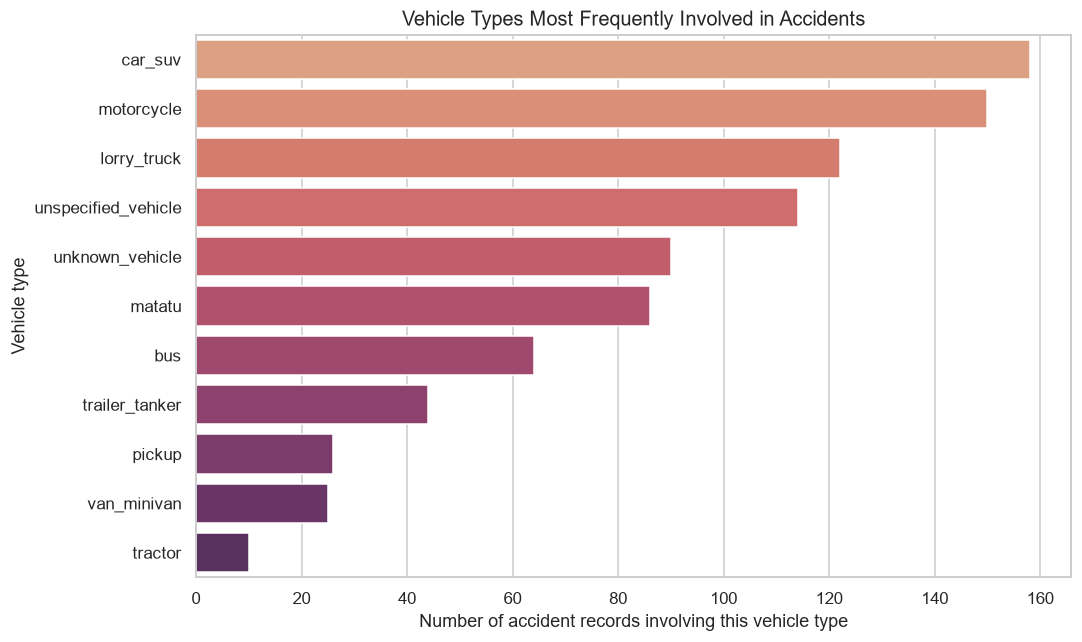

In [71]:
vehicle_cols = ["motorcycle", "matatu", "bus", "lorry_truck", "pickup",
                 "tractor", "car_suv", "trailer_tanker", "van_minivan",
                 "unknown_vehicle", "unspecified_vehicle"]
vehicle_cols = [c for c in vehicle_cols if c in df.columns]
 
vehicle_totals = df[vehicle_cols].sum().sort_values(ascending=False)
 
plt.figure(figsize=(10, 6))
sns.barplot(x=vehicle_totals.values, y=vehicle_totals.index, palette="flare", hue=vehicle_totals.index, legend=False)
plt.title("Vehicle Types Most Frequently Involved in Accidents", fontsize=13)
plt.xlabel("Number of accident records involving this vehicle type")
plt.ylabel("Vehicle type")
plt.tight_layout()
plt.show()
 

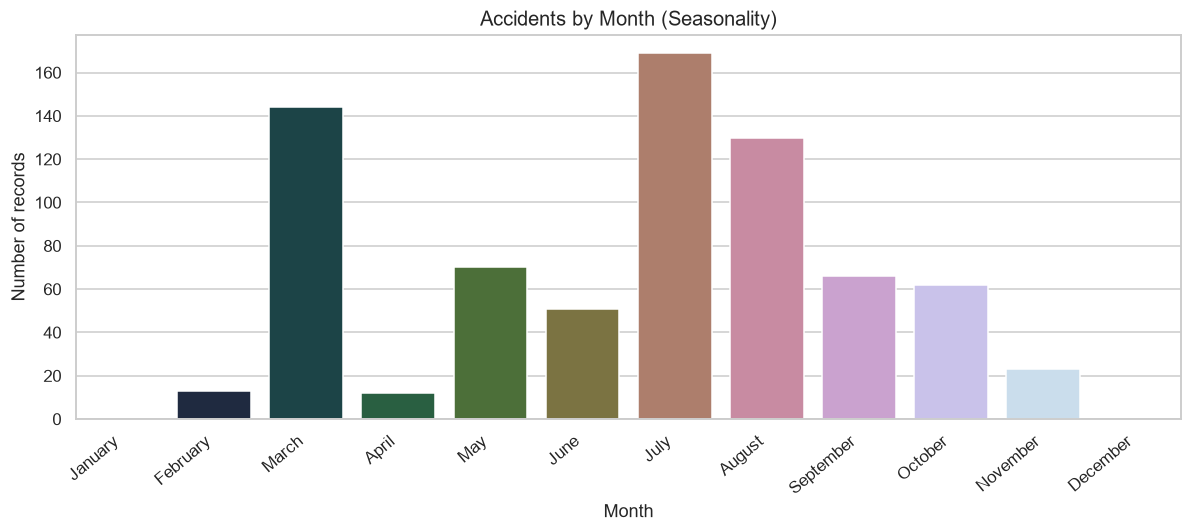

In [73]:
month_order = ["January", "February", "March", "April", "May", "June",
                "July", "August", "September", "October", "November", "December"]
df["month_name_title"] = df["month_name"].str.title()
monthly = df["month_name_title"].value_counts().reindex(month_order)
 
plt.figure(figsize=(11, 5))
sns.barplot(x=monthly.index, y=monthly.values, palette="cubehelix", hue=monthly.index, legend=False)
plt.title("Accidents by Month (Seasonality)", fontsize=13)
plt.xlabel("Month")
plt.ylabel("Number of records")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()
 

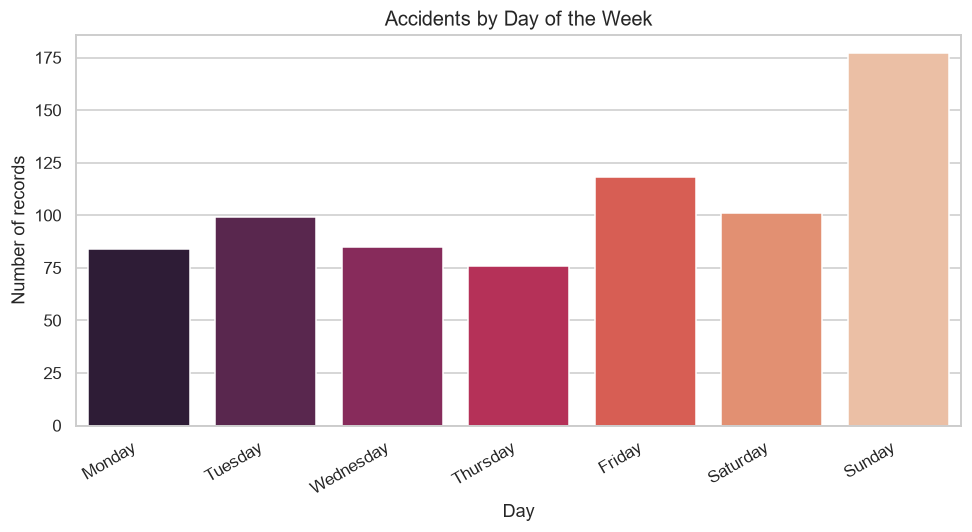

In [74]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["day_name_title"] = df["day_name"].str.title()
daily = df["day_name_title"].value_counts().reindex(day_order)
 
plt.figure(figsize=(9, 5))
sns.barplot(x=daily.index, y=daily.values, palette="rocket", hue=daily.index, legend=False)
plt.title("Accidents by Day of the Week", fontsize=13)
plt.xlabel("Day")
plt.ylabel("Number of records")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
 

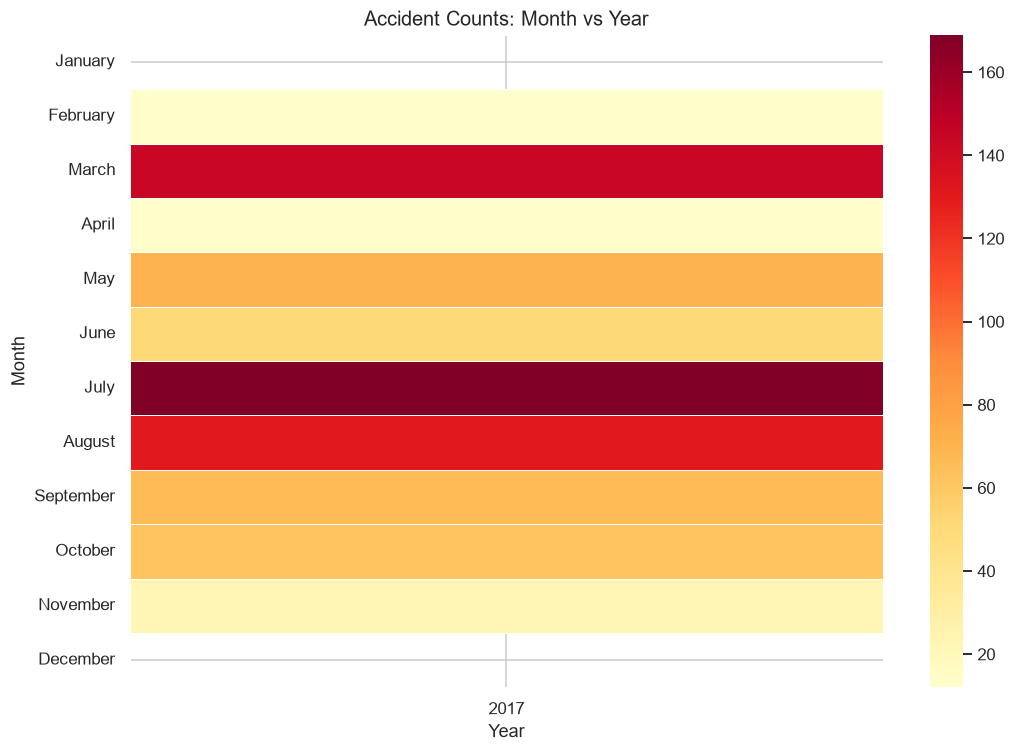

In [75]:
# Heatmap: year x month, to spot patterns across time at once
heat_data = df.pivot_table(index="month_name_title", columns="year",
                            values="accident_id", aggfunc="count").reindex(month_order)
 
plt.figure(figsize=(10, 7))
sns.heatmap(heat_data, cmap="YlOrRd", linewidths=0.5, annot=False)
plt.title("Accident Counts: Month vs Year", fontsize=13)
plt.xlabel("Year")
plt.ylabel("Month")
plt.tight_layout()
plt.show()
 

### Q9. Are there identifiable road accident hotspots in the dataset?
 There's no latitude/longitude in this data, so a true map isn't possible
 without geocoding `county` + `place` first (e.g. via a geocoding API).
 As a proxy, we identify hotspots as the county×road combinations with the
 highest accident density, and visualize county-level intensity as a heatmap
 against cause_group to see *where* certain causes cluster.
 

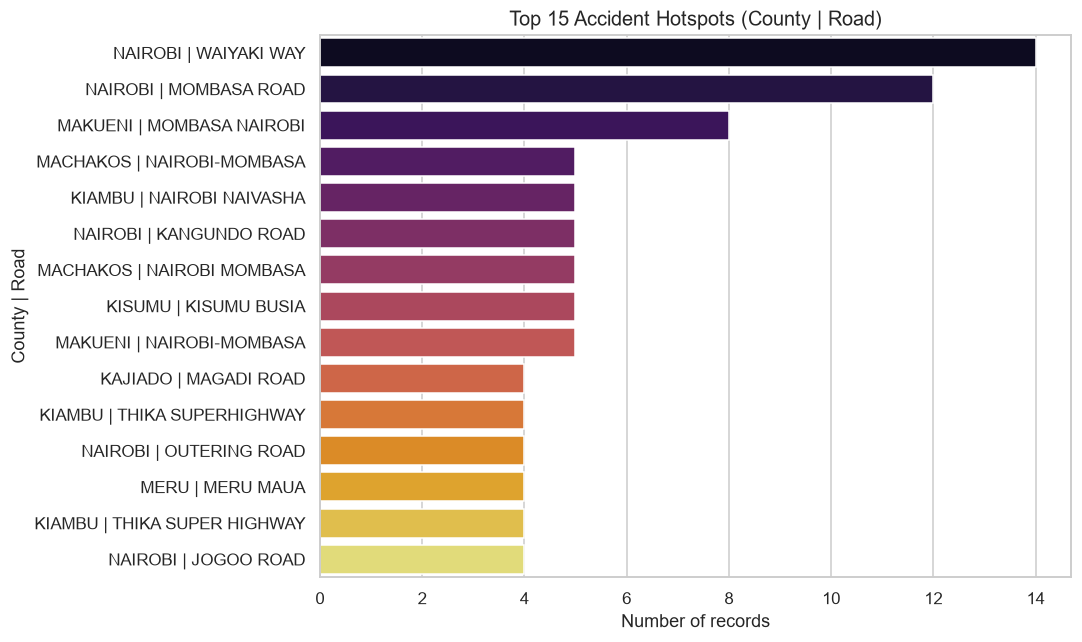

In [76]:
df["county_road"] = df["county"].fillna("UNKNOWN") + " | " + df["road"].fillna("UNKNOWN")
hotspots = df["county_road"].value_counts().head(15)
 
plt.figure(figsize=(10, 6))
sns.barplot(x=hotspots.values, y=hotspots.index, palette="inferno", hue=hotspots.index, legend=False)
plt.title("Top 15 Accident Hotspots (County | Road)", fontsize=13)
plt.xlabel("Number of records")
plt.ylabel("County | Road")
plt.tight_layout()
plt.show()

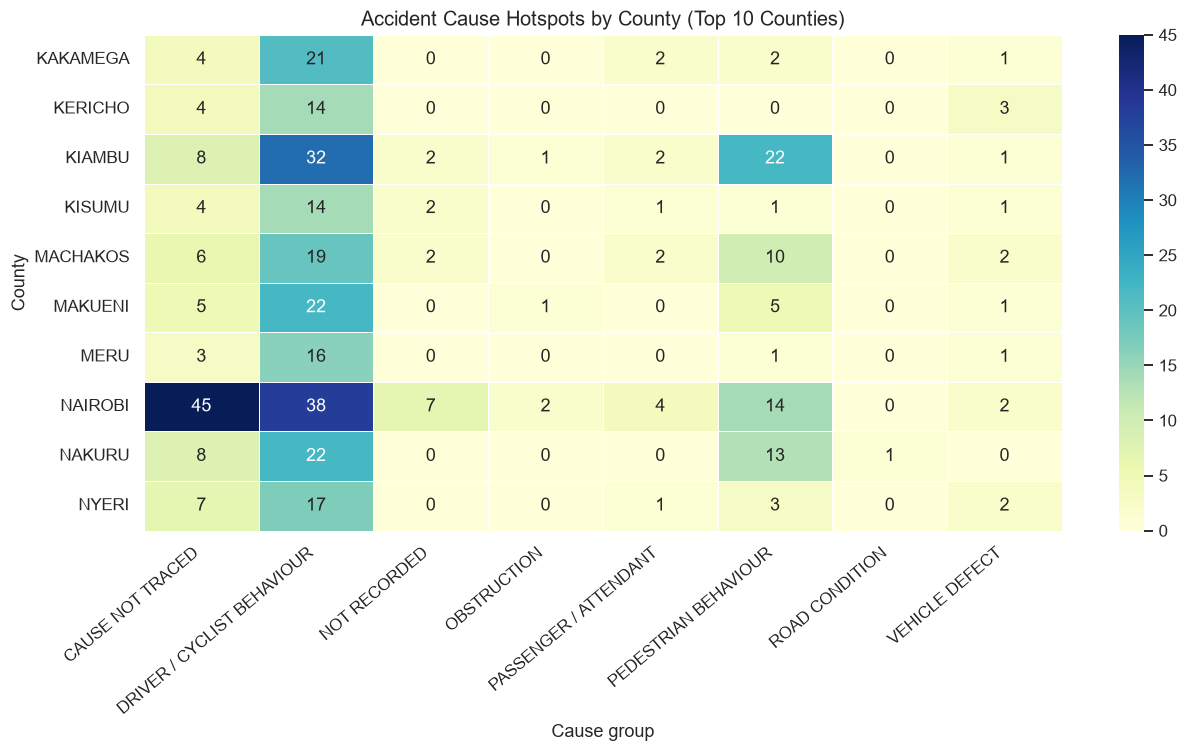

In [77]:
# Cross-tab: top counties vs top cause groups — reveals whether certain
# counties are hotspots for specific causes (e.g. pedestrian behaviour vs
# driver behaviour)
top10_counties = df["county"].value_counts().head(10).index
cross = pd.crosstab(
    df[df["county"].isin(top10_counties)]["county"],
    df[df["county"].isin(top10_counties)]["cause_group"]
)
 
plt.figure(figsize=(12, 7))
sns.heatmap(cross, cmap="YlGnBu", annot=True, fmt="d", linewidths=0.5)
plt.title("Accident Cause Hotspots by County (Top 10 Counties)", fontsize=13)
plt.xlabel("Cause group")
plt.ylabel("County")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()


### A1. Age group breakdown
 Complements victim_type/gender with a third "who" lens — pairs well with
 a cross-cut of age × victim type (are children mostly pedestrians? working-
 age adults mostly motorcyclists?).

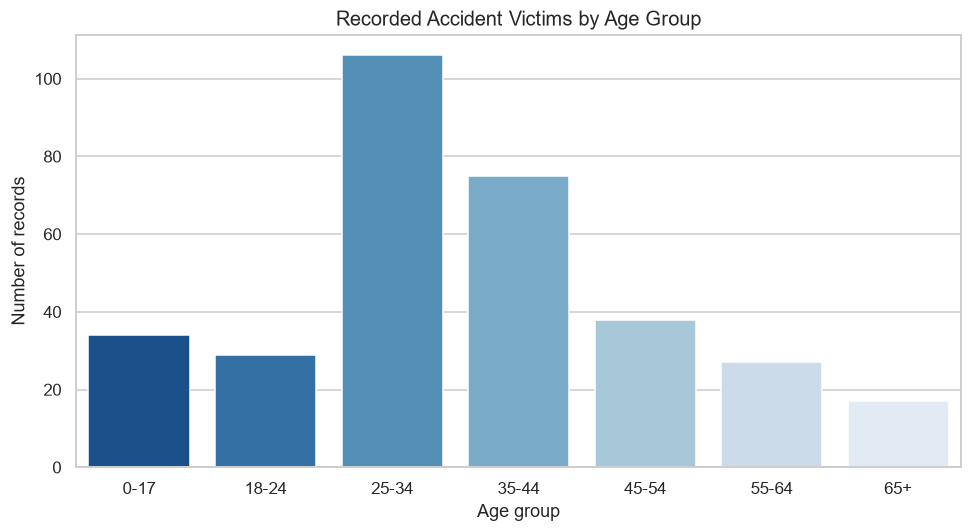

In [78]:
age_order = ["0-17", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
df["age_group"] = df["age_group"].astype(str).str.strip().str.upper()
age_counts = df["age_group"].value_counts().reindex(age_order).dropna()
 
plt.figure(figsize=(9, 5))
sns.barplot(x=age_counts.index, y=age_counts.values,
            hue=age_counts.index, palette="Blues_r", legend=False)
plt.title("Recorded Accident Victims by Age Group", fontsize=13)
plt.xlabel("Age group")
plt.ylabel("Number of records")
plt.tight_layout()
plt.show()
 

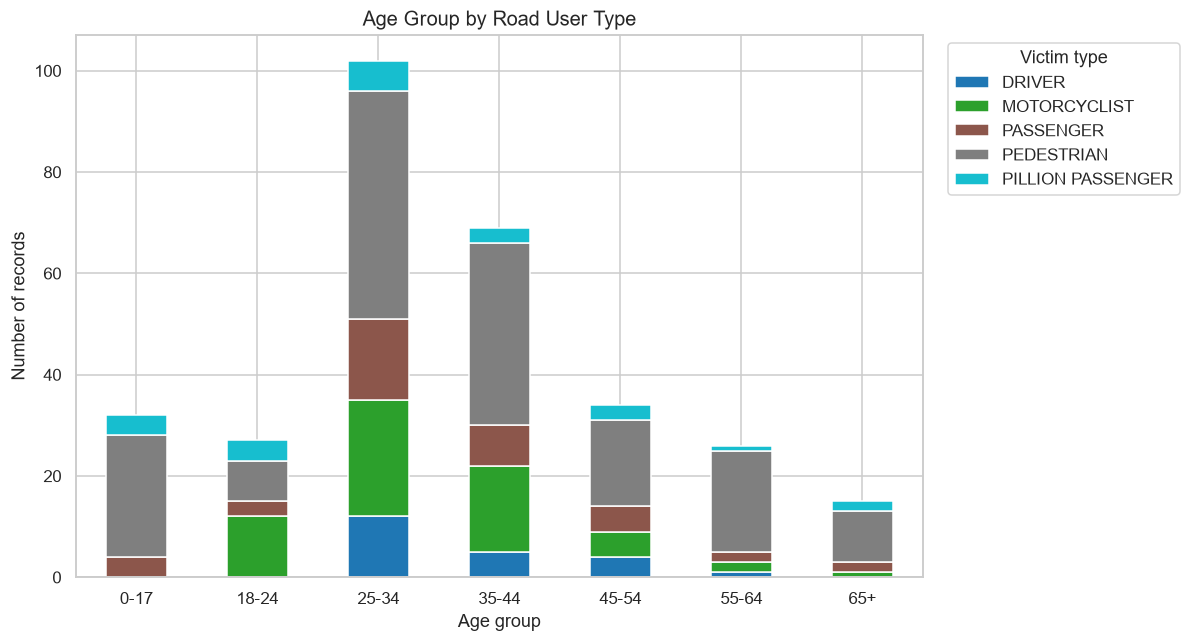

In [79]:
top_victim_types_age = df["victim_type"].value_counts().head(5).index
age_victim = (
    df[df["victim_type"].isin(top_victim_types_age) & df["age_group"].isin(age_order)]
    .groupby(["age_group", "victim_type"])
    .size()
    .unstack(fill_value=0)
    .reindex(age_order)
)
 
age_victim.plot(kind="bar", stacked=True, figsize=(11, 6), colormap="tab10")
plt.title("Age Group by Road User Type", fontsize=13)
plt.xlabel("Age group")
plt.ylabel("Number of records")
plt.xticks(rotation=0)
plt.legend(title="Victim type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
 

### A2. Pareto charts — where to focus limited resources
Bars = raw count, line = cumulative %. Strong "these top N explain most of the problem" argument. Reusable helper, applied to causes and roads.

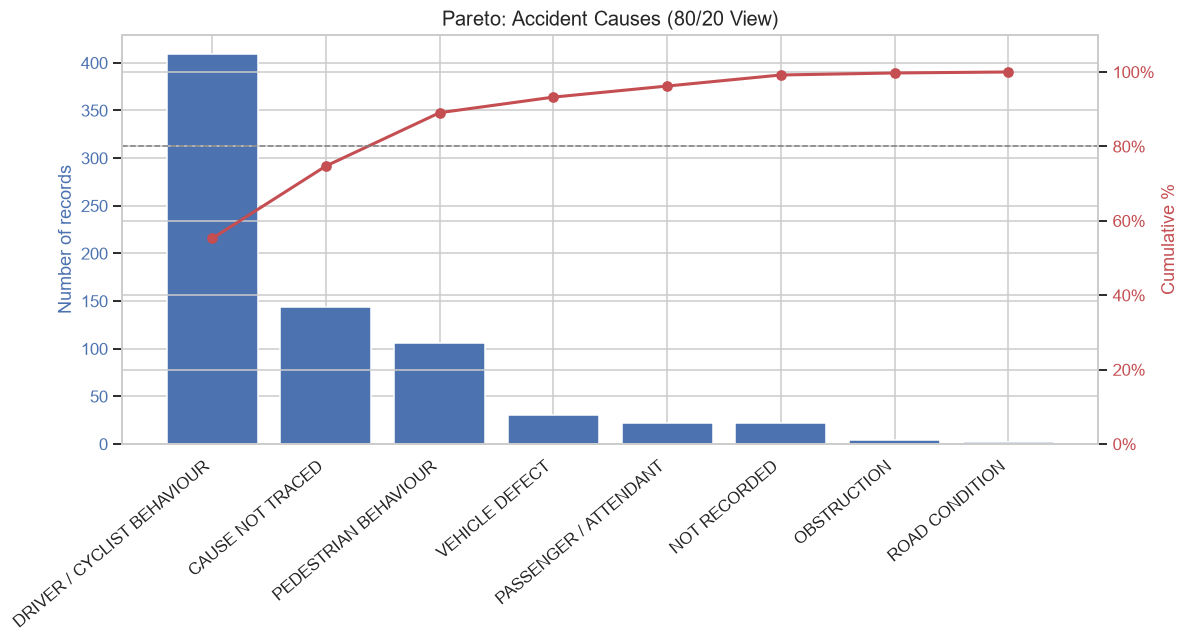

In [8]:
def pareto_chart(series, title, top_n=10):
    counts = series.value_counts().head(top_n)
    cum_pct = counts.cumsum() / series.value_counts().sum() * 100
 
    fig, ax1 = plt.subplots(figsize=(11, 6))
    ax1.bar(counts.index, counts.values, color="#4C72B0")
    ax1.set_ylabel("Number of records", color="#4C72B0")
    ax1.tick_params(axis="y", labelcolor="#4C72B0")
    ax1.set_xticks(range(len(counts.index)))
    ax1.set_xticklabels(counts.index, rotation=40, ha="right")
 
    ax2 = ax1.twinx()
    ax2.plot(counts.index, cum_pct.values, color="#C44E52", marker="o", linewidth=2)
    ax2.axhline(80, linestyle="--", color="grey", linewidth=1)
    ax2.set_ylim(0, 110)
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax2.set_ylabel("Cumulative %", color="#C44E52")
    ax2.tick_params(axis="y", labelcolor="#C44E52")
 
    plt.title(title, fontsize=13)
    plt.tight_layout()
    plt.show()
 
pareto_chart(df["cause_group"], "Pareto: Accident Causes (80/20 View)")

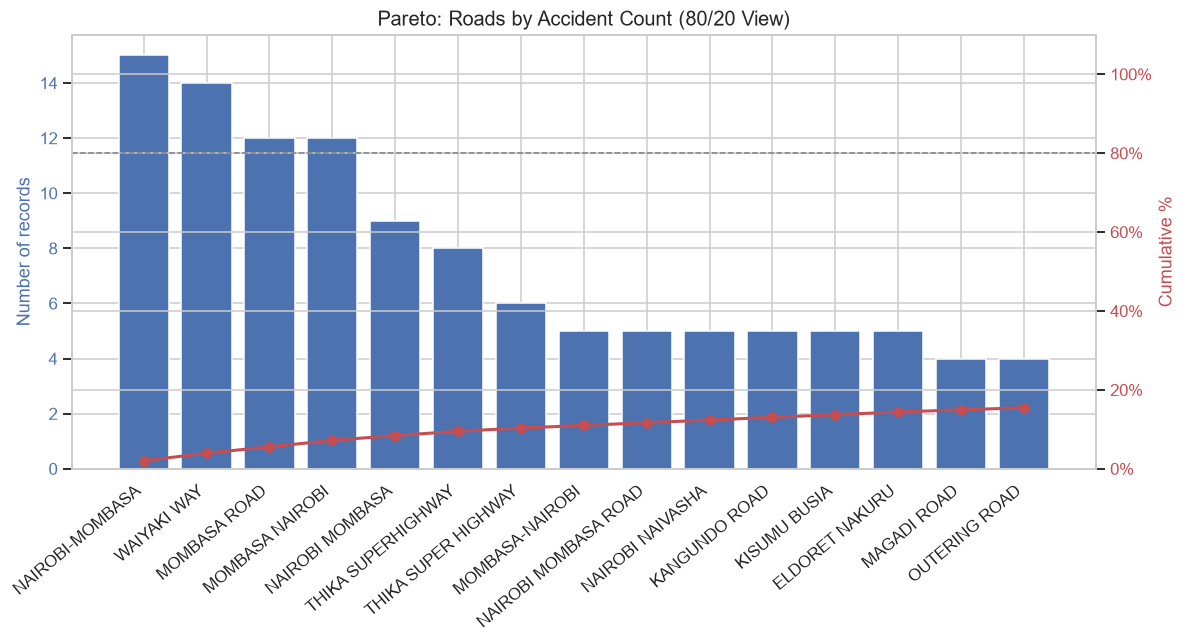

In [9]:
pareto_chart(df["road"], "Pareto: Roads by Accident Count (80/20 View)", top_n=15)


### A3. Day × time "risk clock"
 Compresses two separate bar charts into one glanceable heatmap — read as
 "Saturday nights are the riskiest slot."
 

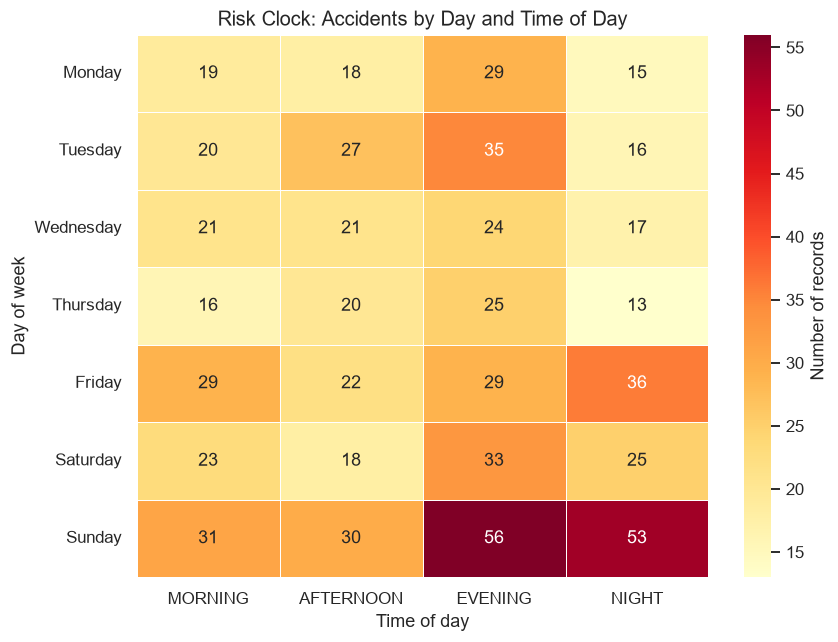

In [82]:
risk_clock = pd.crosstab(df["day_name_title"], df["time_period"])
risk_clock = risk_clock.reindex(index=day_order, columns=period_order)
 
plt.figure(figsize=(8, 6))
sns.heatmap(risk_clock, cmap="YlOrRd", annot=True, fmt="d", linewidths=0.5,
            cbar_kws={"label": "Number of records"})
plt.title("Risk Clock: Accidents by Day and Time of Day", fontsize=13)
plt.xlabel("Time of day")
plt.ylabel("Day of week")
plt.tight_layout()
plt.show()
 

### A4. Severity — how many victims per crash event?
 `accident_id` in this dataset is a row/record id, not a shared crash id —
 a single crash with multiple victims can appear as several rows (same
 date/time/road/place/vehicles, different victim_type), or as one row with
 `number` > 1. To get a defensible severity view, we reconstruct distinct
 crash events with a composite key and sum `number` per event.
 

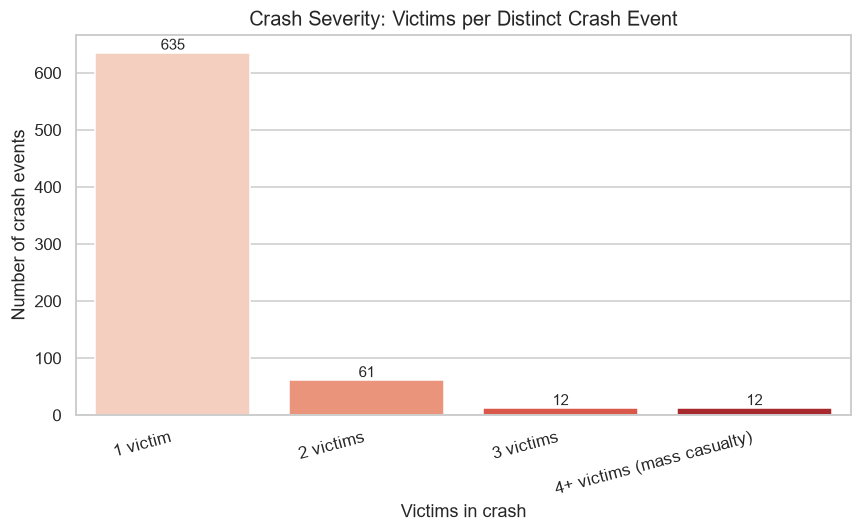

Share of crashes that are mass-casualty (4+ victims): 1.7%


In [83]:
crash_key_cols = ["date", "time", "road", "place", "vehicles_involved"]
crash_key_cols = [c for c in crash_key_cols if c in df.columns]
 
# .astype(str) alone is not enough on modern pandas: genuine missing values
# survive as real float NaN even inside a "str"-dtype column, which then
# breaks a python-level "|".join(). fillna() after astype(str) cleans that up.
key_df = df[crash_key_cols].astype(str).fillna("UNKNOWN")
df["crash_key"] = key_df.agg("|".join, axis=1)
 
severity = df.groupby("crash_key")["number"].sum()
 
def bucket_severity(n):
    if n <= 1:
        return "1 victim"
    elif n == 2:
        return "2 victims"
    elif n == 3:
        return "3 victims"
    else:
        return "4+ victims (mass casualty)"
 
bucket_order = ["1 victim", "2 victims", "3 victims", "4+ victims (mass casualty)"]
severity_buckets = severity.apply(bucket_severity).value_counts().reindex(bucket_order).fillna(0)
 
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=severity_buckets.index, y=severity_buckets.values,
                  hue=severity_buckets.index, palette="Reds", legend=False)
plt.title("Crash Severity: Victims per Distinct Crash Event", fontsize=13)
plt.xlabel("Victims in crash")
plt.ylabel("Number of crash events")
plt.xticks(rotation=15, ha="right")
for i, v in enumerate(severity_buckets.values):
    ax.text(i, v, str(int(v)), ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()
 
print(f"Share of crashes that are mass-casualty (4+ victims): "
      f"{(severity >= 4).mean() * 100:.1f}%")
 

### A5. Choropleth map — accident intensity by county
 
 

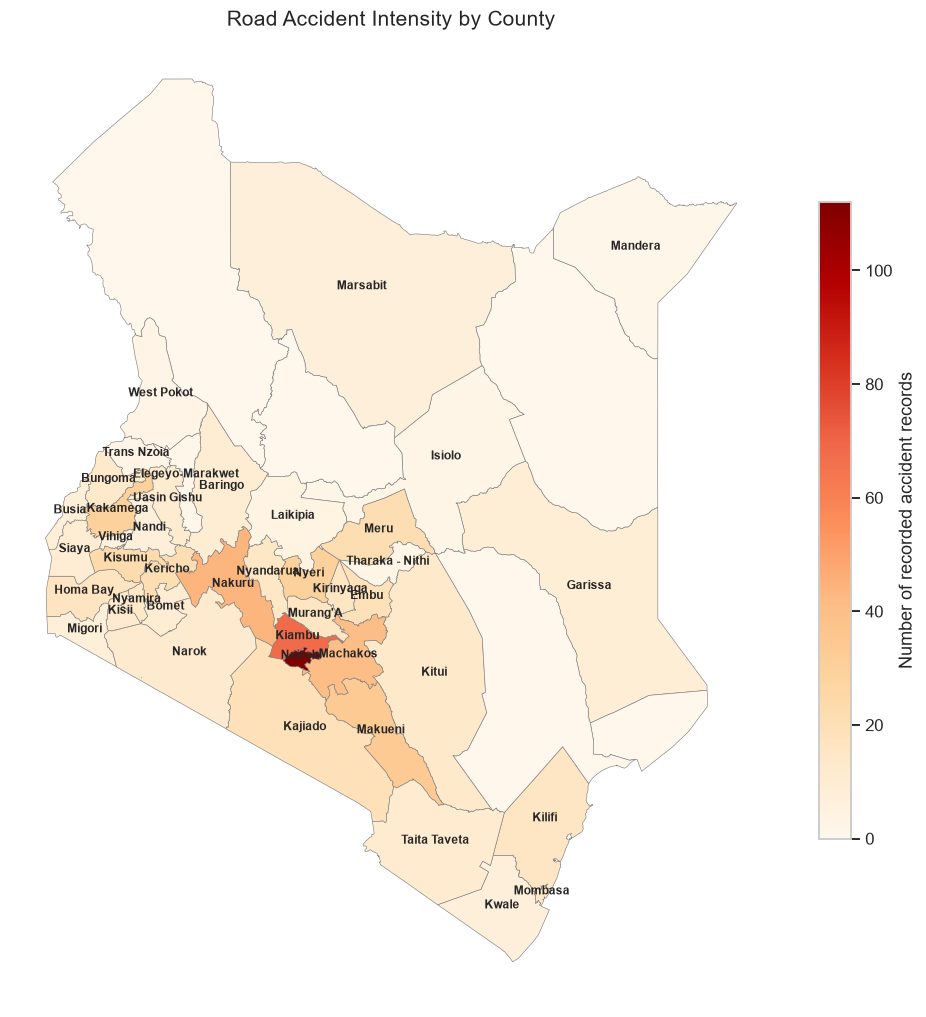

In [84]:
import requests
import geopandas as gpd
 
GEOJSON_URL = "https://raw.githubusercontent.com/mikelmaron/kenya-election-data/master/data/counties.geojson"
 
# Fetched via requests rather than geopandas' own URL loader — more portable
# across environments/proxies that GDAL's built-in curl sometimes struggles with.
resp = requests.get(GEOJSON_URL, timeout=30)
resp.raise_for_status()
kenya = gpd.read_file(io.BytesIO(resp.content))
kenya = kenya.dropna(subset=["COUNTY_NAM"])
kenya = kenya.dissolve(by="COUNTY_NAM").reset_index()   # constituency polygons -> county polygons
 
def normalize_name(name):
    return re.sub(r"[^A-Z]", "", str(name).upper())   # letters only
 
manual_overrides = {
    "ELGEYOMARAKWET": "ELEGEYOMARAKWET",
}
 
kenya["county_norm"] = kenya["COUNTY_NAM"].apply(normalize_name)
 
county_totals = df["county"].value_counts().rename_axis("county").reset_index(name="accidents")
county_totals["county_norm"] = county_totals["county"].apply(normalize_name)
county_totals["county_norm"] = county_totals["county_norm"].replace(manual_overrides)
 
kenya_map = kenya.merge(county_totals[["county_norm", "accidents"]], on="county_norm", how="left")
kenya_map["accidents"] = kenya_map["accidents"].fillna(0)
 
unmatched = set(county_totals["county_norm"]) - set(kenya["county_norm"])
if unmatched:
    print("Unmatched counties — check spelling / extend manual_overrides:", unmatched)
 
# %%
fig, ax = plt.subplots(figsize=(9, 10))
kenya_map.plot(
    column="accidents", cmap="OrRd", linewidth=0.4, edgecolor="grey",
    legend=True, legend_kwds={"label": "Number of recorded accident records", "shrink": 0.6},
    ax=ax,
)
ax.set_title("Road Accident Intensity by County", fontsize=14)
ax.axis("off")
 
# Label the top 5 counties directly on the map
top5 = county_totals.nlargest(42, "accidents")["county_norm"].tolist()
for _, row in kenya_map[kenya_map["county_norm"].isin(top5)].iterrows():
    centroid = row["geometry"].centroid
    ax.annotate(row["COUNTY_NAM"].title(), xy=(centroid.x, centroid.y),
                fontsize=8, ha="center", weight="bold")
 
plt.tight_layout()
plt.show()
 